# iPhone Resale Analysis

This project analyzes the US iPhone resale market using a dataset of 2,371 listings sourced from Kaggle. The goal is to understand what factors influence iPhone resale prices, which models are most actively traded, and how pricing varies across the United States. The analysis was conducted using Python, Pandas, and Matplotlib.
Note: This dataset reflects a snapshot of the resale market and may not represent all listings. Some columns such as sold and storage contained missing values which were handled appropriately throughout the analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_iphone = pd.read_csv("data/iphone_data.csv")
print(df_iphone.shape)
df_iphone.head()

(2371, 16)


,title,model_family,generation_number,is_pro,storage_options_gb,storage_gb_numeric,condition,price,wasPrice,price_discount_pct,available,sold,seller,itemLocation,us_state,lastUpdated
0,Apple iPhone 14 128gb RED color (Factory Unloc...,iPhone 14,14,False,128GB,128.0,Used,329.99,NaN,NaN,NaN,NaN,Seller 019,"Granada Hills, California, United States",CA,1/2/2026
1,Lot of 10 Apple iPhone 12 Pro 128GB Unlocked M...,iPhone 12 Pro,12,True,128GB,128.0,Used,3160.00,NaN,NaN,NaN,NaN,Seller 332,"Winter Park, Florida, United States",FL,3/1/2026
2,Apple iPhone 14 Pro MAX 128GB FULLY Unlocked,iPhone 14 Pro Max,14,True,128GB,128.0,Used,726.99,NaN,NaN,3.0,NaN,Seller 019,"Granada Hills, California, United States",CA,12/12/2025
3,Apple iPhone 14 Pro MAX 256gb Space black (Fac...,iPhone 14 Pro Max,14,True,256GB,256.0,Used,669.99,NaN,NaN,NaN,NaN,Seller 019,"Granada Hills, California, United States",CA,12/12/2025
4,Apple iPhone 14 Pro MAX 512gb Deep purple (Fac...,iPhone 14 Pro Max,14,True,512GB,512.0,Used,659.99,NaN,NaN,2.0,NaN,Seller 019,"Granada Hills, California, United States",CA,3/10/2026


In [3]:
print(df_iphone.isnull().sum())
print(df_iphone['condition'].unique())
print(df_iphone['condition'].value_counts())

title                    0
model_family             0
generation_number        0
is_pro                   0
storage_options_gb     203
storage_gb_numeric     203
condition                0
price                    0
wasPrice              2237
price_discount_pct    2237
available             1149
sold                  1459
seller                   0
itemLocation             1
us_state                 1
lastUpdated            415
dtype: int64
['Used' 'Very Good - Refurbished' 'Open Box' 'Excellent - Refurbished'
 'For Parts Or Not Working' 'New' 'Good - Refurbished']
condition
Used                        1105
New                          682
Open Box                     228
For Parts Or Not Working     114
Excellent - Refurbished       96
Very Good - Refurbished       95
Good - Refurbished            51
Name: count, dtype: int64


In [4]:
condition_map = {
    'New': 'New / Like New',
    'Open Box' : 'New / Like New',
    'Used' : 'Used',
    'Excellent - Refurbished' : 'Refurbished',
    'Very Good - Refurbished' : 'Refurbished', 
    'Good - Refurbished' : 'Refurbished',
    'For Parts Or Not Working' : 'For Parts'
}

df_iphone['condition_clean'] = df_iphone['condition'].map(condition_map)
print(df_iphone['condition_clean'].value_counts())

condition_clean
Used              1105
New / Like New     910
Refurbished        242
For Parts          114
Name: count, dtype: int64


## Which condition has the highest average resale price?

In [5]:
condition_avg = df_iphone.groupby('condition_clean')['price'].mean()
print(condition_avg)

condition_clean
For Parts         223.366053
New / Like New    650.523209
Refurbished       524.591281
Used              406.623258
Name: price, dtype: float64


In [6]:
condition_avg = condition_avg.sort_values(ascending = False)
print(condition_avg)

condition_clean
New / Like New    650.523209
Refurbished       524.591281
Used              406.623258
For Parts         223.366053
Name: price, dtype: float64


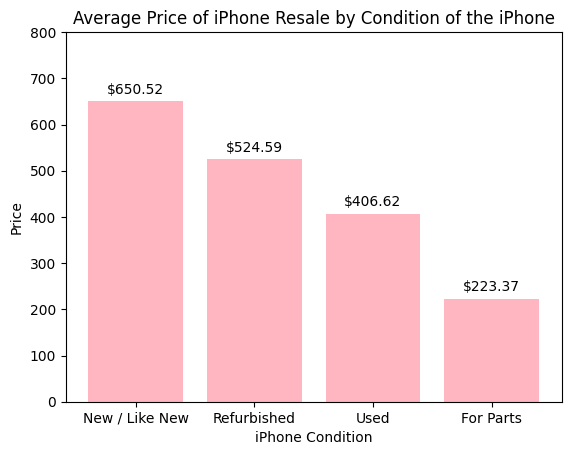

In [7]:
condition_bars = plt.bar(
    condition_avg.index,
    condition_avg.values, 
    color = 'lightpink'
)

for bar in condition_bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 10, f"${round(yval, 2)}",
        ha='center',
        va='bottom'
    )

plt.title("Average Price of iPhone Resale by Condition of the iPhone")
plt.xlabel("iPhone Condition")
plt.ylabel("Price")
plt.ylim(0, 800)
plt.show()

As expected, New or Like New iPhones command the highest average resale price at $650.52, followed by Refurbished at $524.59, Used at $406.62, and For Parts at $233.37. Notably, the price gap between New and Refurbished is only $125.93, suggesting that Refurbished iPhones offer strong value for buyers seeking new-new quality at a lower price point. This relatively small gap could make it challenging for sellers of new devices to justify the premium. 

## How does storage size affect iPhone resale price?

In [8]:
print(df_iphone['storage_gb_numeric'].unique())
print(df_iphone['storage_gb_numeric'].value_counts())

[ 128.  256.  512. 1024.   nan   64. 2048.   12.   28.   50.  125.]
storage_gb_numeric
128.0     1086
256.0      443
64.0       320
512.0      235
1024.0      60
2048.0      19
12.0         2
28.0         1
50.0         1
125.0        1
Name: count, dtype: int64


In [9]:
valid_storage = [64, 128, 256, 512, 1024]
df_storage = df_iphone[df_iphone['storage_gb_numeric'].isin(valid_storage)]
print(df_storage.shape)

(2144, 17)


In [10]:
df_storage.groupby('storage_gb_numeric')['price'].mean()

storage_avg = df_storage.groupby('storage_gb_numeric')['price'].mean()
storage_avg = storage_avg.sort_values(ascending = False)
print(storage_avg)

storage_gb_numeric
1024.0    923.193000
256.0     756.875305
512.0     620.259660
128.0     365.802155
64.0      183.642875
Name: price, dtype: float64


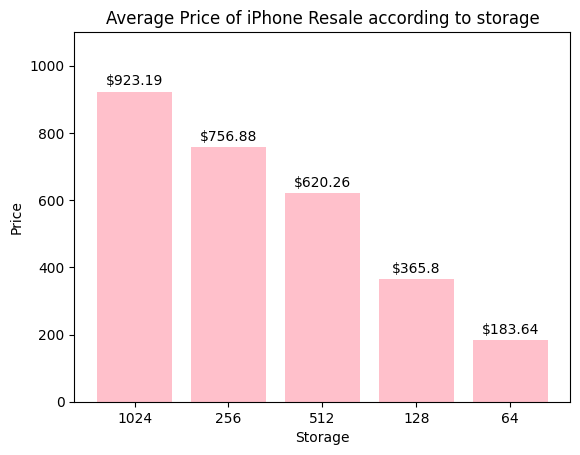

In [11]:
storage_avg.index = storage_avg.index.astype(int).astype(str)

storage_bars = plt.bar(
    storage_avg.index, 
    storage_avg.values, 
    color = 'pink'
)

for bar in storage_bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 10, 
        f"${round(yval, 2)}", 
        ha = 'center', 
        va = 'bottom'
    )

plt.title("Average Price of iPhone Resale according to storage")
plt.xlabel("Storage")
plt.ylabel("Price")
plt.ylim(0, 1100)
plt.show()

As expected, storage size generally correlates with resale price. The 1024GB tier commands the highest average price at $923.19 while 64GB sits lowest at $183.64. However, an interesting anomaly emerges where 256GB ($756.88) outprices 512GB($620.26). This suggests that storage size alone does not determine resale value. Factors such as iPhone model and generation likely play a significant role, as newer models tend to come in 256GB configurations while older models dominate the 512GB tier.

## Which iPhone models sell the most?

In [22]:
print(df_iphone['sold'].isnull().sum())
print(df_iphone['sold'].value_counts().head(10))

1459
sold
1.0     228
2.0     124
3.0      71
5.0      42
4.0      42
6.0      31
7.0      20
8.0      18
14.0     13
10.0     11
Name: count, dtype: int64


In [23]:
df_sold = df_iphone.dropna(subset=['sold'])
print(df_sold.shape)

(912, 17)


In [24]:
df_model_sold = df_sold.groupby('model_family')['sold'].sum()
df_model_sold = df_model_sold.sort_values(ascending = False)
print(df_model_sold.head(10))

model_family
iPhone 15 Pro Max    48450.0
iPhone 15 Pro        19952.0
iPhone 15            18730.0
iPhone 14            12742.0
iPhone 13             9870.0
iPhone 12             9614.0
iPhone 12 Pro Max     6767.0
iPhone 16             6640.0
iPhone 13 Mini        4213.0
iPhone 15 Plus        3480.0
Name: sold, dtype: float64


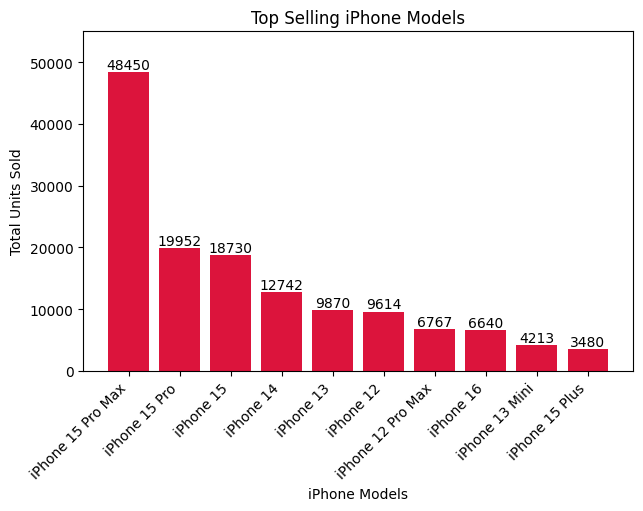

In [25]:
df_top10_models = df_model_sold.head(10)

model_bars = plt.bar(
    df_top10_models.index, 
    df_top10_models.values, 
    color = 'crimson'
)

for bar in model_bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 10, 
        int(yval), 
        ha='center', va = 'bottom'
    )

plt.xticks(rotation =45, ha='right')
plt.tight_layout()
plt.title("Top Selling iPhone Models")
plt.xlabel("iPhone Models")
plt.ylabel("Total Units Sold")
plt.ylim(0, 55000)
plt.show()

The iPhone 15 Pro Max dominates the resale market with 48,450 units sold, significantly outselling the second place iPhone 15 Pro at 19,952 units. Notably, all four iPhone 15 family models appear in the top 10, including the iPhones 15 Plus at rank 10 with 3,480 units sold. Despite the iPhone 16 and 17 being available, the iPhone 15 family remains the most active in the reslae market. This aligns with typical consumer behavior where the release of newer models drives previous generation oweners to resell their devices, making the most recently superseded generration the most actively traded on the reslae market. 

## Which US states have the highest average iPhone resale price and how many listings does each state have?

In [16]:
print(df_iphone['us_state'].value_counts().head(10))

us_state
TX      669
NJ      339
CA      294
NY      257
FL      209
INTL    149
OH       69
KS       42
AZ       29
IL       26
Name: count, dtype: int64


In [17]:
df_us = df_iphone[df_iphone['us_state'] != 'INTL']
df_us = df_us.dropna(subset = ['us_state'])
print(df_us.shape)

(2221, 17)


In [18]:
state_avg = df_us.groupby('us_state')['price'].mean()
state_avg = state_avg.sort_values(ascending = False)
print(state_avg.head(10))

us_state
NM    1394.995000
AL    1366.666667
GA    1343.030000
AR    1263.990000
IN    1229.381538
CO    1182.665000
NC    1073.983333
WY    1000.000000
VA     993.520000
OR     978.235000
Name: price, dtype: float64


In [19]:
state_stats = df_us.groupby('us_state')['price'].agg(['mean', 'count'])
print(state_stats.sort_values('count', ascending = False).head(10))

                mean  count
us_state                   
TX        281.820045    669
NJ        484.104277    339
CA        612.820816    294
NY        506.824436    257
FL        588.091531    209
OH        343.498406     69
KS        564.196429     42
AZ        825.158276     29
IL        365.739615     26
MD        719.228400     25


In [20]:
state_reliable = state_stats[state_stats['count'] >= 20]
state_reliable = state_reliable.sort_values('mean', ascending = False)
print(state_reliable.head(10))

                mean  count
us_state                   
PA        873.422609     23
AZ        825.158276     29
MD        719.228400     25
CA        612.820816    294
FL        588.091531    209
KS        564.196429     42
MI        535.567391     23
NY        506.824436    257
NJ        484.104277    339
IL        365.739615     26


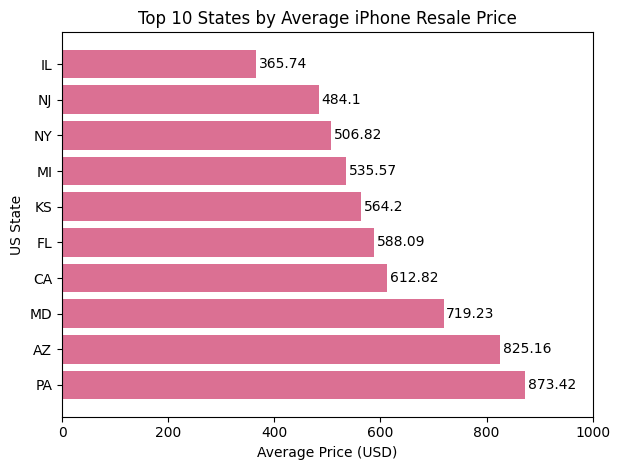

In [21]:
top10_states = state_reliable.head(10)

state_bars = plt.barh(
    top10_states.index, 
    top10_states['mean'], 
    color='palevioletred'
)

for bar in state_bars:
    xval = bar.get_width()
    plt.text(
        xval + 5, 
        bar.get_y() + bar.get_height()/2, 
        f"{round(xval, 2)}", 
        ha='left', va='center'
    )

plt.title("Top 10 States by Average iPhone Resale Price")
plt.xlabel("Average Price (USD)")
plt.ylabel("US State")
plt.tight_layout()
plt.xlim(0, 1000)
plt.show()

Among states with 20 or more listings for statistical reliablity, Pennsylvania leads with the highest average iPhone resale price at $873.42, followed by Arizona at $825.16 and Maryland at $719.23. Interestingly, Illinois ranks lowest in the group at $365.74 despite having 26 listings. The price difference between the highest and lowest states is approximately $508, suggesting that geographic location plays a meaningful role in iPhone resale pricing across the US.

This project analyzes the US iPhone resale market using a dataset of 2,371 listings sourced from Kaggle. The goal is to understand what factors influence iPhone resale prices, which models are most actively traded, and how pricing varies across the United States. The analysis was conducted using Python, Pandas, and Matplotlib.
Note: This dataset reflects a snapshot of the resale market and may not represent all listings. Some columns such as sold and storage contained missing values which were handled appropriately throughout the analysis.